In [1]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA

from trajan.data import TracksDataFrame
from trajan.features import compute_trajectory_features

warnings.filterwarnings('ignore')
SEED = 42
DT_RANGE = (50, 120)  # must match GCN training config
N_SAMPLES_PER_TRACK = 10

## 1. Data loading and feature computation
Computes features on **full trajectories** and on **random subtrajectories** of length sampled
from `DT_RANGE`, matching the GCN training setup for a fair comparison.

In [3]:
tracks_path = os.path.join("data", "cytoplasmic", "tracks.csv")
data = pd.read_csv(tracks_path, skiprows=1)
data = TracksDataFrame(data, frame_rate=10)

# Full trajectory features
features_df = data.compute_features()

# Sampled subtrajectory features — matches GCN training setup
def compute_features_sampled(
    df: TracksDataFrame,
    Dt_range: tuple,
    n_samples_per_track: int = 10,
    seed: int = 42,
) -> pd.DataFrame:
    """Compute features from randomly sampled subtrajectories.

    Parameters
    ----------
    df : TracksDataFrame
        Tracking data.
    Dt_range : tuple[int, int]
        Min and max subtrajectory length in frames, matching the GCN setup.
    n_samples_per_track : int, optional
        Number of random windows to sample per trajectory. Default is 10.
    seed : int, optional
        Random seed. Default is 42.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for video in df['set'].unique():
        df_video = df[df['set'] == video]
        for label in df_video['label'].unique():
            track = df_video[df_video['label'] == label].sort_values('frame')
            coords = track[['x', 'y']].to_numpy()
            T = len(coords)

            for _ in range(n_samples_per_track):
                Dt = int(rng.integers(Dt_range[0], Dt_range[1] + 1))
                if T < Dt:
                    continue
                start = int(rng.integers(0, T - Dt + 1))
                sub_coords = coords[start:start + Dt]

                features = compute_trajectory_features(sub_coords, frame_rate=df.frame_rate)
                features['set'] = video
                features['label'] = label
                if 'type' in df.columns:
                    features['type'] = track['type'].iloc[0]
                rows.append(features)

    return pd.DataFrame(rows)

features_sampled_df = compute_features_sampled(data, DT_RANGE, N_SAMPLES_PER_TRACK, SEED)

print(f"Full trajectory features:    {len(features_df)} trajectories")
print(f"Sampled subtrajectory features: {len(features_sampled_df)} samples")
print(f"  ({N_SAMPLES_PER_TRACK} samples x {features_df['type'].value_counts().to_dict()} trajectories)")

Full trajectory features:    573 trajectories
Sampled subtrajectory features: 3239 samples
  (10 samples x {'endosome': 339, 'postgolgi': 131, 'golgi': 103} trajectories)


In [33]:
features_df

,mean_speed,std_speed,alpha,diffusion_coeff,confinement_index,radius_of_gyration,max_displacement,net_displacement,confinement_ratio,pause_fraction,...,mean_local_alpha,std_local_alpha,range_local_alpha,non_gaussianity,kurtosis,turning_angle_entropy,asymmetry,set,label,type
0,2.639123,1.705470,1.033530,0.274705,0.140288,3.394588,10.132348,9.458894,0.100677,0.075843,...,1.033346,0.459152,2.376512,0.366554,2.039246,2.026599,0.860246,0,0,endosome
1,2.082875,2.120733,1.041375,0.119233,0.099545,1.876768,5.667345,5.639156,0.129540,0.191388,...,0.738665,0.682514,3.411170,1.421840,2.485426,1.806935,0.957678,0,1,endosome
2,1.404417,1.228889,1.432168,0.228724,0.088002,1.058393,4.086029,4.086029,0.454596,0.000000,...,1.013547,0.376924,1.847387,1.374277,3.982141,1.994643,0.983876,0,2,endosome
3,2.090684,1.426976,1.006505,0.166998,0.146338,1.120055,5.887390,2.194221,0.044851,0.021368,...,1.023253,0.438491,2.204048,0.510611,2.691195,2.013310,0.677137,0,3,endosome
4,1.872219,1.342938,1.419742,0.298885,0.076282,1.318887,4.372918,4.231098,0.551204,0.024390,...,1.091534,0.374173,1.457520,0.737825,3.202177,1.949865,0.979243,0,4,endosome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568,2.198544,1.360457,1.362236,0.329061,0.081625,1.981185,7.019001,6.923555,0.384043,0.024390,...,1.229701,0.422951,2.130866,0.395469,2.503236,1.809376,0.919854,35,10,postgolgi
569,1.518115,0.729190,1.193096,0.118618,0.124179,0.898246,2.099548,1.878345,0.127555,0.000000,...,1.270598,0.253563,1.299671,-0.106577,-0.499871,2.006456,0.439853,36,0,postgolgi
570,1.225284,0.649197,1.231956,0.081730,0.108989,0.850886,2.408551,2.034463,0.171175,0.000000,...,1.291659,0.252350,1.333329,-0.024325,-0.289179,2.018371,0.929084,36,1,postgolgi
571,1.705839,1.056667,1.093682,0.137331,0.147791,0.758065,1.795451,1.270709,0.076796,0.010309,...,1.168554,0.407103,1.861486,0.143563,-0.136972,1.955728,0.512523,37,0,postgolgi


In [4]:
FEATURE_COLS = [
    # Diffusion
    'mean_speed', 'std_speed', 'alpha', 'diffusion_coeff', 'confinement_index',
    # Confinement
    'radius_of_gyration', 'max_displacement', 'net_displacement',
    'confinement_ratio', 'pause_fraction',
    # Directionality
    'velocity_autocorr_lag1', 'vacf_decay', 'straightness',
    'mean_turning_angle', 'std_turning_angle',
    'directionality_ratio_short', 'directionality_ratio_mid',
    # Local alpha
    'mean_local_alpha', 'std_local_alpha', 'range_local_alpha',
    # Statistical
    'non_gaussianity', 'kurtosis', 'turning_angle_entropy',
    # Asymmetry
    'asymmetry',
]

features_clean = features_df.dropna(subset=FEATURE_COLS).copy()
features_sampled_clean = features_sampled_df.dropna(subset=FEATURE_COLS).copy()

print(f"Full — after dropping NaNs: {len(features_clean)} / {len(features_df)}")
print(f"Sampled — after dropping NaNs: {len(features_sampled_clean)} / {len(features_sampled_df)}")
print(f"\nFull class distribution:")
print(features_clean['type'].value_counts())
print(f"\nSampled class distribution:")
print(features_sampled_clean['type'].value_counts())

Full — after dropping NaNs: 525 / 573
Sampled — after dropping NaNs: 3239 / 3239

Full class distribution:
type
endosome     296
postgolgi    130
golgi         99
Name: count, dtype: int64

Sampled class distribution:
type
endosome     1748
postgolgi     771
golgi         720
Name: count, dtype: int64


## 2. Feature exploration
Distributions and pairplot on full trajectory features.

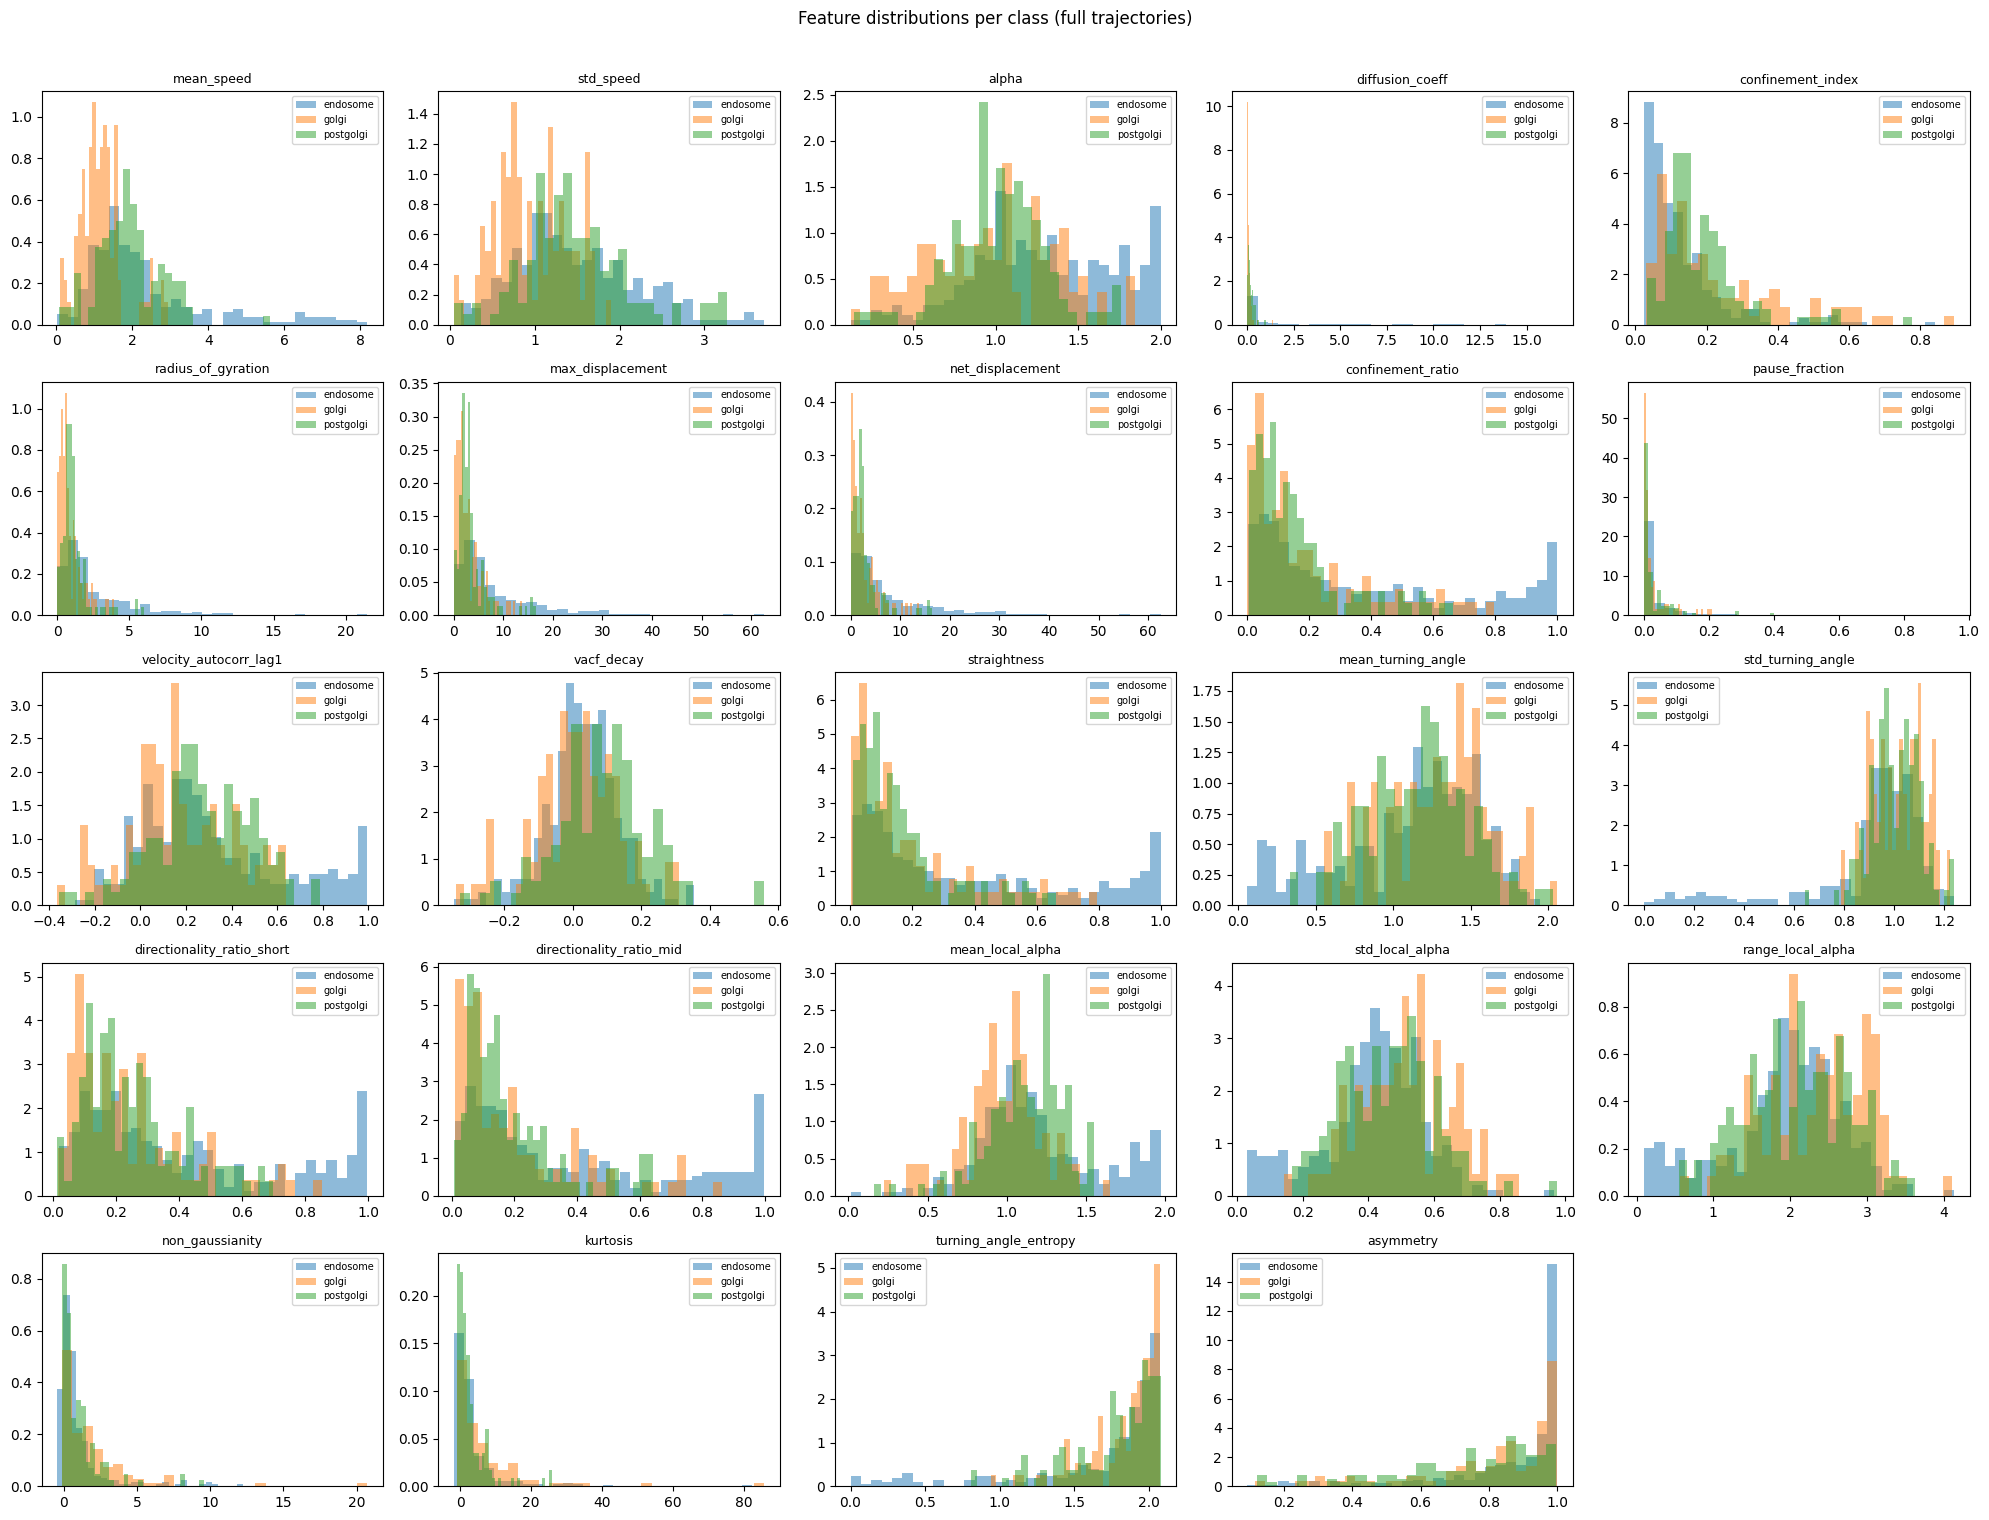

In [5]:
n_cols = 5
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    for particle_type in features_clean['type'].unique():
        vals = features_clean[features_clean['type'] == particle_type][feat].dropna()
        axes[i].hist(vals, bins=30, alpha=0.5, label=particle_type, density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions per class (full trajectories)', y=1.01)
plt.tight_layout()
plt.savefig("classical_features")

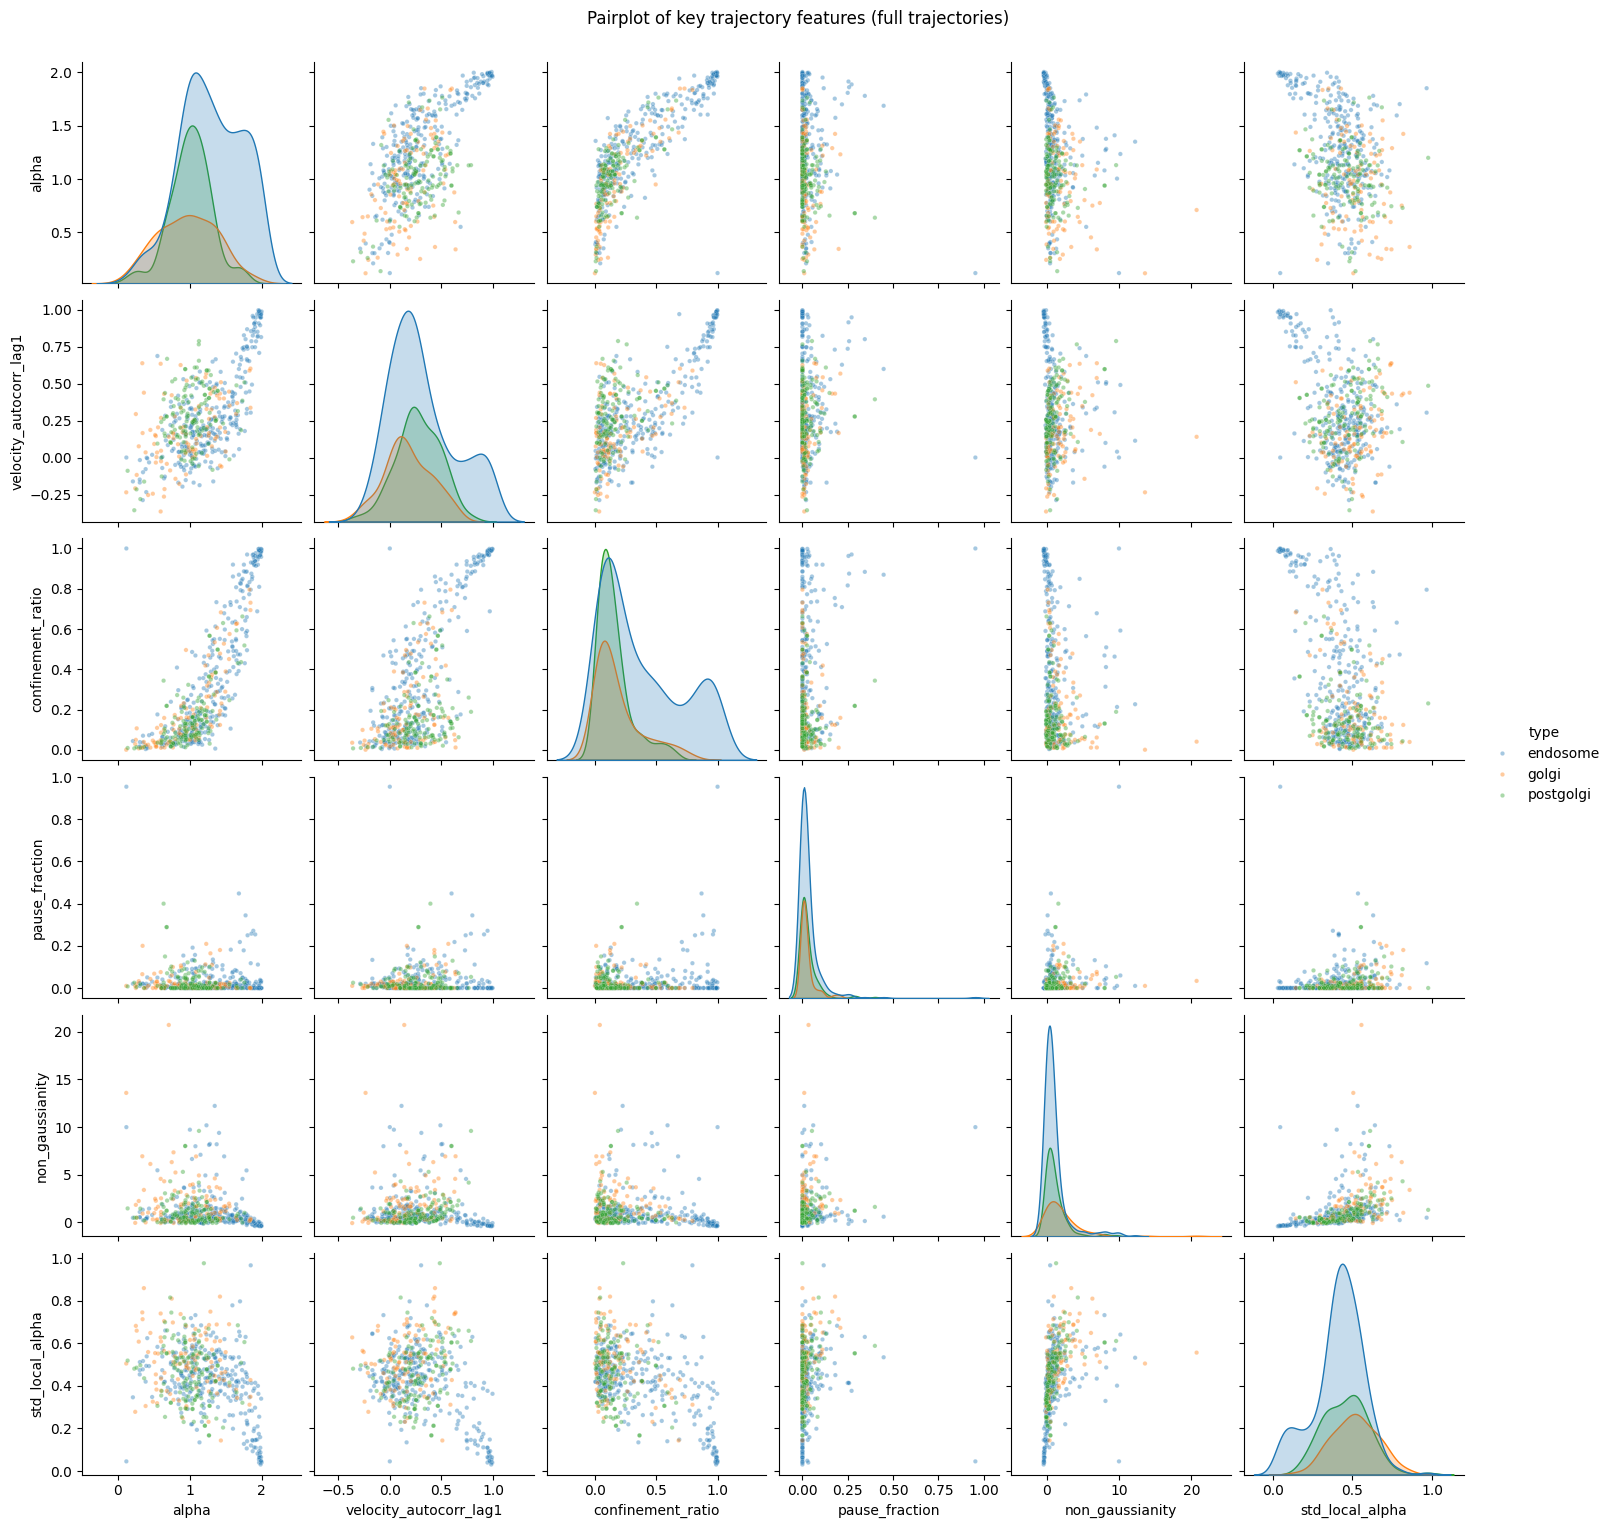

In [6]:
key_features = [
    'alpha', 'velocity_autocorr_lag1', 'confinement_ratio',
    'pause_fraction', 'non_gaussianity', 'std_local_alpha', 'type'
]
sns.pairplot(features_clean[key_features].dropna(), hue='type', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pairplot of key trajectory features (full trajectories)', y=1.02)
plt.savefig("classical_features_per_class")

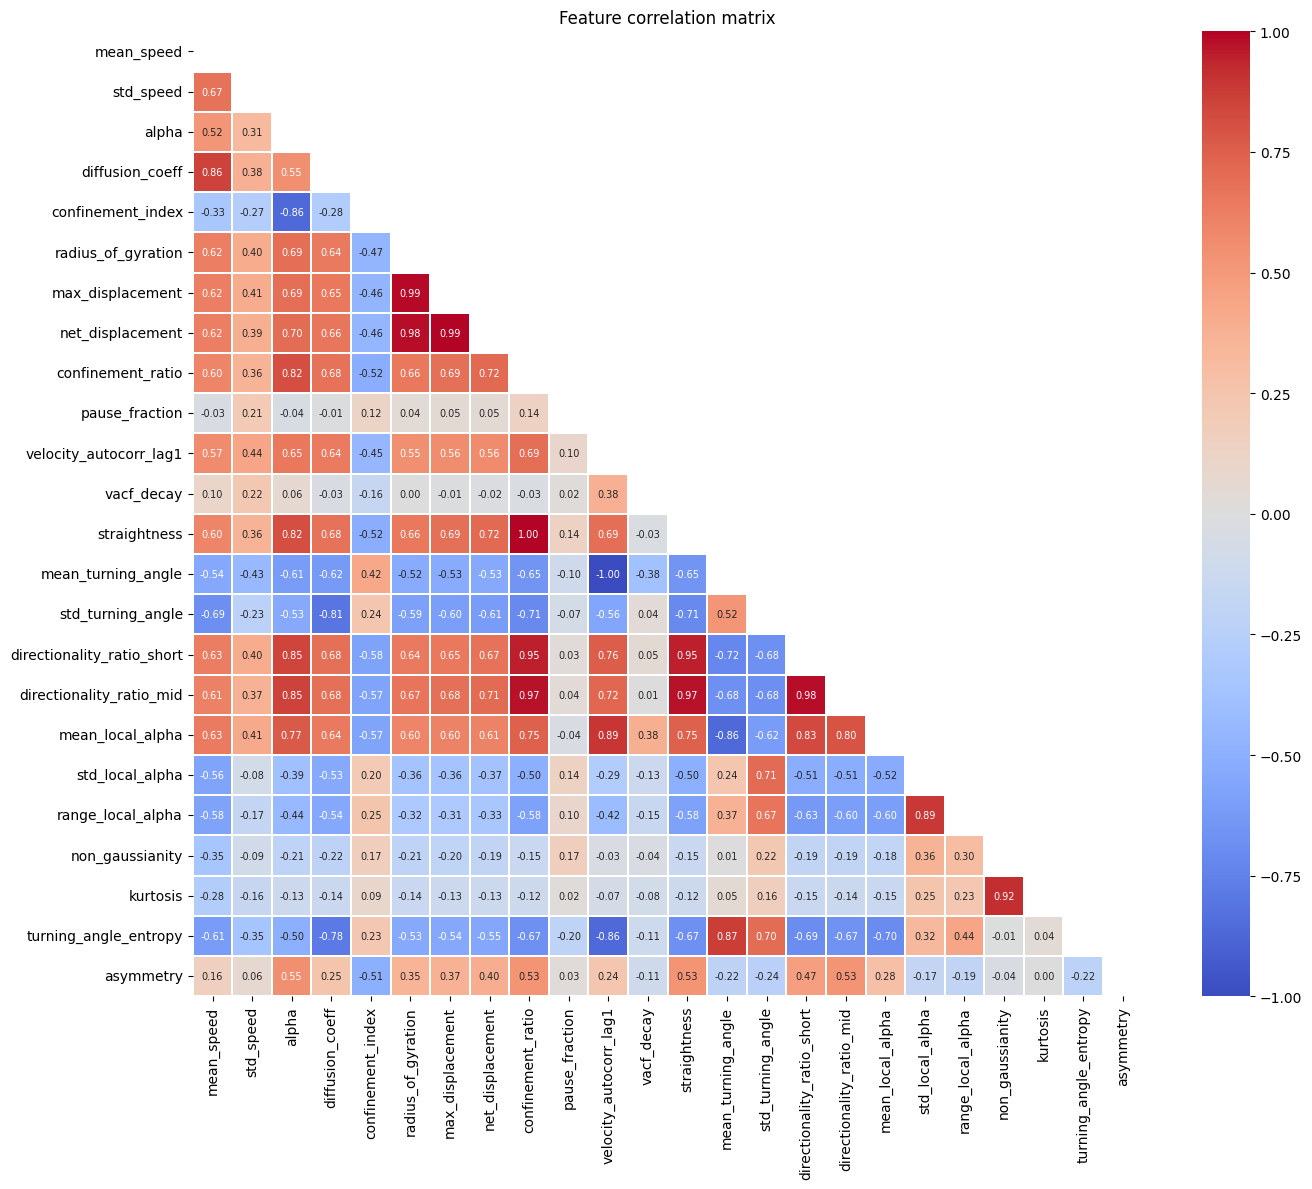

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = features_clean[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    ax=ax, vmin=-1, vmax=1, annot_kws={'size': 7}, linewidths=0.3,
)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig("feature_correlation_matrix")

## 3. PCA
Side-by-side PCA for full and sampled features — shows whether subtrajectory sampling preserves class separability in feature space.

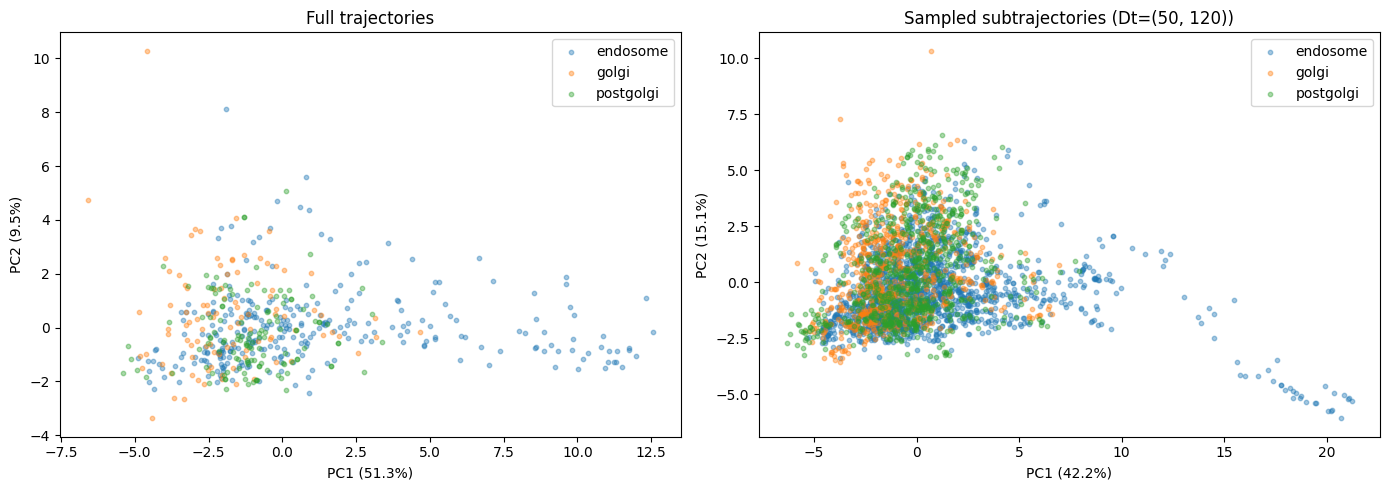

In [8]:
le = LabelEncoder()
le.fit(features_clean['type'].values)
class_names = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(
    axes,
    [features_clean, features_sampled_clean],
    ['Full trajectories', f'Sampled subtrajectories (Dt={DT_RANGE})'],
):
    X = df[FEATURE_COLS].values
    y_enc = le.transform(df['type'].values)

    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X_scaled)

    for i, cls in enumerate(class_names):
        mask = y_enc == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, alpha=0.4, s=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("features_PCA")
plt.show()

## 4. Train/test split
Recording-wise split, consistent with the GCN pipeline. Applied to both full and sampled features.

In [ ]:
rng = np.random.default_rng(SEED)
test_recordings = []

for particle_type in features_clean['type'].unique():
    recordings = features_clean[features_clean['type'] == particle_type]['set'].unique()
    print(recordings)
    n_test = max(1, int(round(len(recordings) * 0.25)))
    print(n_test)
    test_recordings.extend(rng.choice(recordings, n_test, replace=False).tolist())
    print(test_recordings)

# Full trajectory split
train_full = features_clean[~features_clean['set'].isin(test_recordings)]
test_full = features_clean[features_clean['set'].isin(test_recordings)]

X_train_full = train_full[FEATURE_COLS].values
y_train_full = le.transform(train_full['type'].values)
X_test_full = test_full[FEATURE_COLS].values
y_test_full = le.transform(test_full['type'].values)

# Sampled subtrajectory split — same recording-level split
train_sampled = features_sampled_clean[~features_sampled_clean['set'].isin(test_recordings)]
test_sampled = features_sampled_clean[features_sampled_clean['set'].isin(test_recordings)]

X_train_sampled = train_sampled[FEATURE_COLS].values
y_train_sampled = le.transform(train_sampled['type'].values)
X_test_sampled = test_sampled[FEATURE_COLS].values
y_test_sampled = le.transform(test_sampled['type'].values)

print(f"Full     — Train: {len(X_train_full)}, Test: {len(X_test_full)}")
print(f"Sampled  — Train: {len(X_train_sampled)}, Test: {len(X_test_sampled)}")

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
5
[13, 8, 11, 1, 19]
[20 21 22 23 24 25 26]
2
[13, 8, 11, 1, 19, 20, 23]
[27 28 29 30 31 32 33 34 35 36 37]
3
[13, 8, 11, 1, 19, 20, 23, 33, 34, 37]


## 5. Model training and cross-validation
Models trained and evaluated on both full and sampled features for a fair comparison with the GCN.

In [11]:
def make_pipelines():
    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, random_state=SEED
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', class_weight='balanced', probability=True, random_state=SEED
        ),
        'KNN': KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    }
    return {
        name: Pipeline([('scaler', StandardScaler()), ('model', model)])
        for name, model in models.items()
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def run_cv(pipelines, X, y, label):
    print(f"\n{'='*50}")
    print(f"Cross-validation: {label}")
    print('='*50)
    results = {}
    for name, pipeline in pipelines.items():
        scores = cross_validate(
            pipeline, X, y, cv=cv,
            scoring=['accuracy', 'balanced_accuracy', 'f1_macro'],
            return_train_score=True,
        )
        results[name] = scores
        print(f"{name}")
        print(f"  val balanced accuracy: {scores['test_balanced_accuracy'].mean():.3f} "
              f"± {scores['test_balanced_accuracy'].std():.3f}")
        print(f"  val macro F1:          {scores['test_f1_macro'].mean():.3f} "
              f"± {scores['test_f1_macro'].std():.3f}")
    return results

pipelines_full    = make_pipelines()
pipelines_sampled = make_pipelines()

cv_results_full    = run_cv(pipelines_full,    X_train_full,    y_train_full,    'Full trajectories')
cv_results_sampled = run_cv(pipelines_sampled, X_train_sampled, y_train_sampled, f'Sampled (Dt={DT_RANGE})')


Cross-validation: Full trajectories
Random Forest
  val balanced accuracy: 0.581 ± 0.055
  val macro F1:          0.597 ± 0.064
Gradient Boosting
  val balanced accuracy: 0.559 ± 0.035
  val macro F1:          0.569 ± 0.041
SVM (RBF)
  val balanced accuracy: 0.626 ± 0.032
  val macro F1:          0.556 ± 0.021
KNN
  val balanced accuracy: 0.467 ± 0.038
  val macro F1:          0.473 ± 0.052

Cross-validation: Sampled (Dt=(50, 120))
Random Forest
  val balanced accuracy: 0.735 ± 0.014
  val macro F1:          0.779 ± 0.013
Gradient Boosting
  val balanced accuracy: 0.729 ± 0.013
  val macro F1:          0.762 ± 0.014
SVM (RBF)
  val balanced accuracy: 0.736 ± 0.010
  val macro F1:          0.693 ± 0.014
KNN
  val balanced accuracy: 0.688 ± 0.016
  val macro F1:          0.722 ± 0.022


In [12]:
def make_summary(cv_results):
    return pd.DataFrame({
        name: {
            'val_accuracy': scores['test_accuracy'].mean(),
            'val_balanced_accuracy': scores['test_balanced_accuracy'].mean(),
            'val_f1_macro': scores['test_f1_macro'].mean(),
            'train_accuracy': scores['train_accuracy'].mean(),
        }
        for name, scores in cv_results.items()
    }).T.round(3)

summary_full    = make_summary(cv_results_full)
summary_sampled = make_summary(cv_results_sampled)

print('Full trajectories:')
display(summary_full)
print('\nSampled subtrajectories:')
display(summary_sampled)

Full trajectories:


,val_accuracy,val_balanced_accuracy,val_f1_macro,train_accuracy
Random Forest,0.740,0.581,0.597,1.000
Gradient Boosting,0.708,0.559,0.569,1.000
SVM (RBF),0.598,0.626,0.556,0.689
KNN,0.672,0.467,0.473,0.734



Sampled subtrajectories:


,val_accuracy,val_balanced_accuracy,val_f1_macro,train_accuracy
Random Forest,0.838,0.735,0.779,1.000
Gradient Boosting,0.824,0.729,0.762,0.982
SVM (RBF),0.725,0.736,0.693,0.758
KNN,0.798,0.688,0.722,0.840


## 6. Evaluation on held-out test set
Side-by-side confusion matrices for full vs sampled features, for each model.

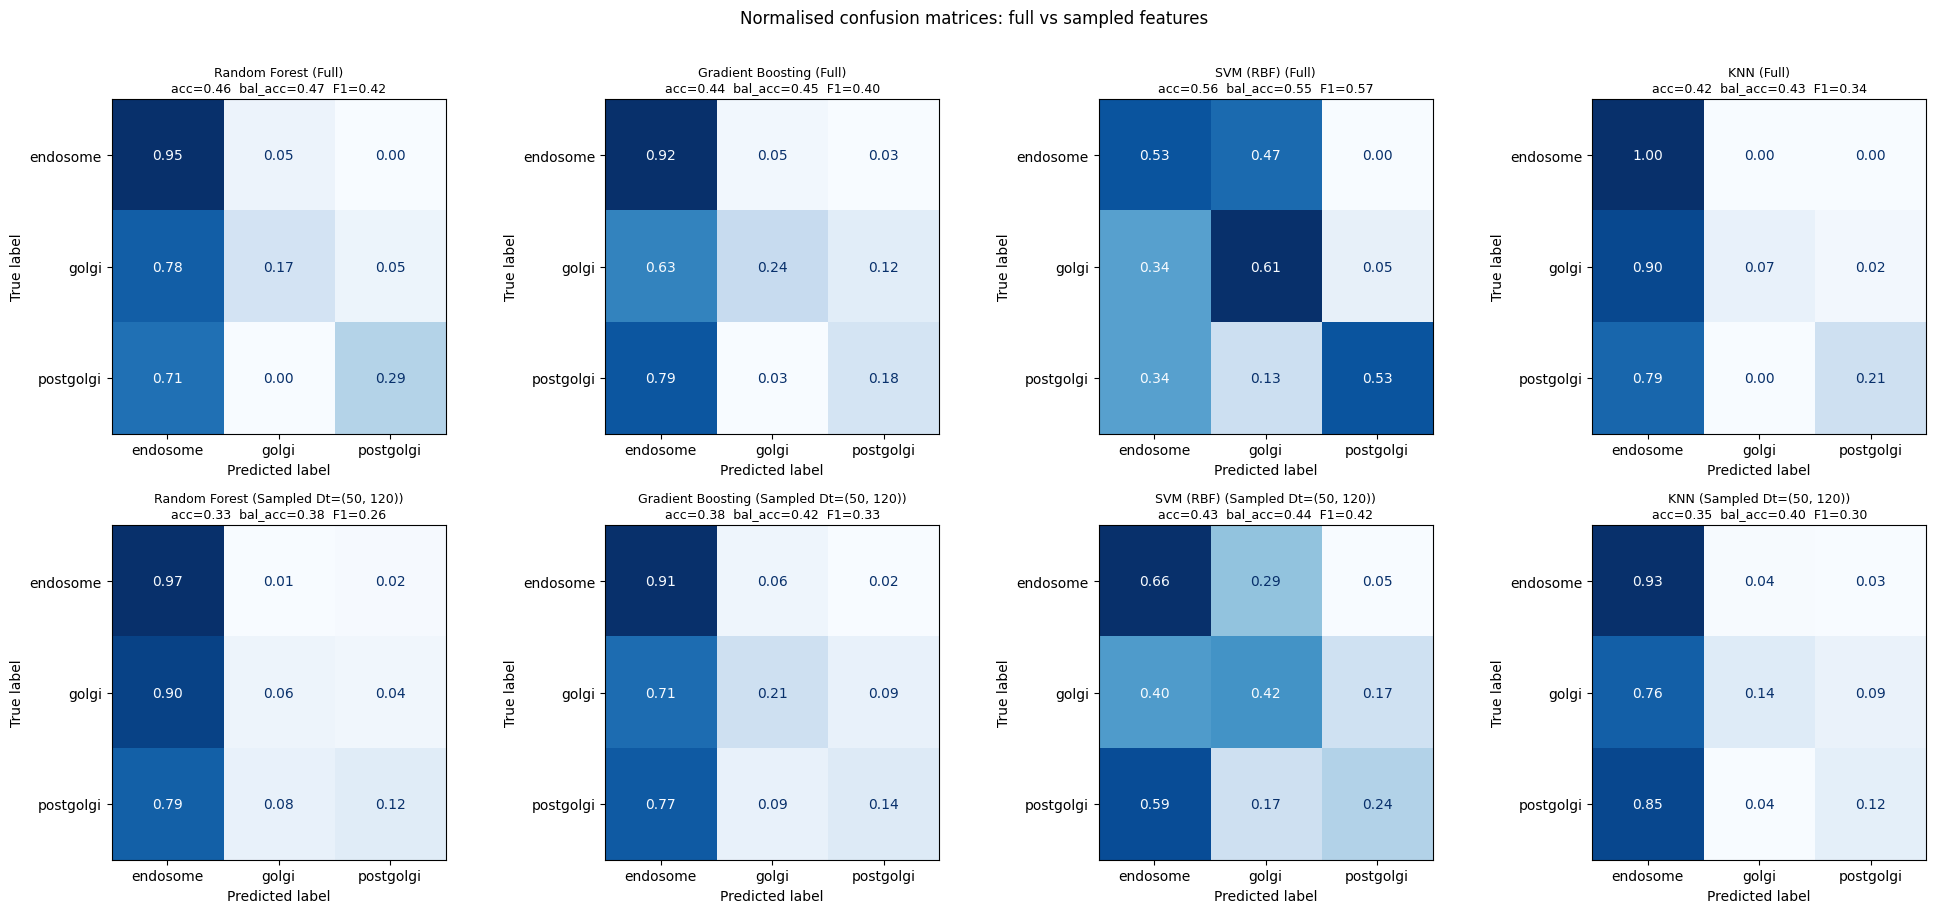

In [13]:
from sklearn.metrics import balanced_accuracy_score, f1_score

model_names = list(pipelines_full.keys())
n_models = len(model_names)

fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 9))

for col, name in enumerate(model_names):
    for row, (pipelines, X_train, y_train, X_test, y_test, label) in enumerate([
        (pipelines_full,    X_train_full,    y_train_full,    X_test_full,    y_test_full,    'Full'),
        (pipelines_sampled, X_train_sampled, y_train_sampled, X_test_sampled, y_test_sampled, f'Sampled Dt={DT_RANGE}'),
    ]):
        pipelines[name].fit(X_train, y_train)
        y_pred = pipelines[name].predict(X_test)

        acc = (y_pred == y_test).mean()
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
            ax=axes[row, col], cmap='Blues', values_format='.2f', colorbar=False
        )
        axes[row, col].set_title(
            f'{name} ({label})\n'
            f'acc={acc:.2f}  bal_acc={bal_acc:.2f}  F1={f1:.2f}',
            fontsize=9,
        )

plt.suptitle('Normalised confusion matrices: full vs sampled features', y=1.01)
plt.tight_layout()
plt.savefig("classical_results.png", bbox_inches='tight', dpi=150)
plt.show()

## 7. Feature importance (Random Forest)
Comparison of feature importances between full and sampled trajectory features.

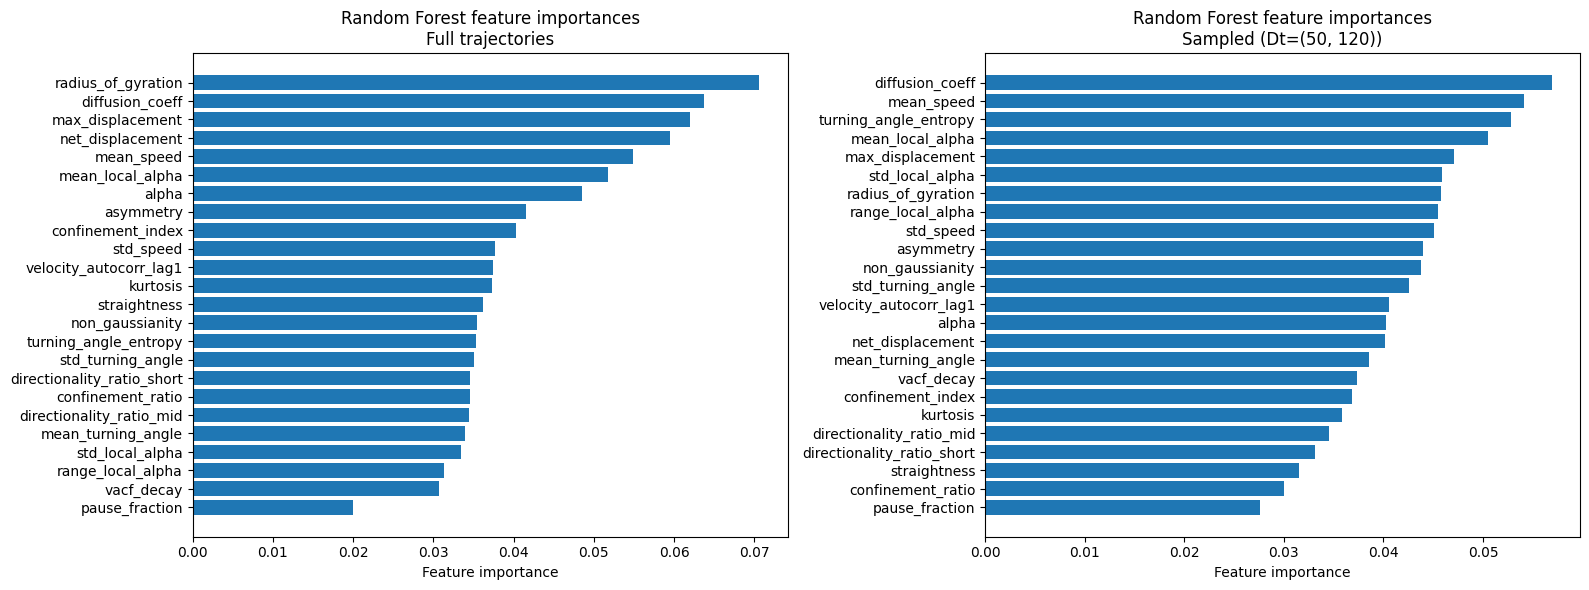

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pipelines, title in zip(
    axes,
    [pipelines_full, pipelines_sampled],
    ['Full trajectories', f'Sampled (Dt={DT_RANGE})'],
):
    importances = pipelines['Random Forest'].named_steps['model'].feature_importances_
    importance_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
    importance_df = importance_df.sort_values('importance', ascending=True)
    ax.barh(importance_df['feature'], importance_df['importance'])
    ax.set_xlabel('Feature importance')
    ax.set_title(f'Random Forest feature importances\n{title}')

plt.tight_layout()
plt.savefig("random_forest_feature_importance")
plt.show()

## 8. Separability assessment
Summary comparing full vs sampled trajectory separability, and what this implies for the GCN.

In [15]:
for summary, label in [
    (summary_full,    'Full trajectories'),
    (summary_sampled, f'Sampled (Dt={DT_RANGE})'),
]:
    best_model = summary['val_balanced_accuracy'].idxmax()
    best_score = summary.loc[best_model, 'val_balanced_accuracy']
    print(f"{label}")
    print(f"  Best model: {best_model} — balanced accuracy: {best_score:.3f}")
    if best_score < 0.5:
        print("  Classes appear not separable from trajectory features alone.")
    elif best_score < 0.7:
        print("  Weak separability. GNN may improve but gains may be limited.")
    else:
        print("  Classes are separable. GNN has room to improve further.")
    print()

Full trajectories
  Best model: SVM (RBF) — balanced accuracy: 0.626
  Weak separability. GNN may improve but gains may be limited.

Sampled (Dt=(50, 120))
  Best model: SVM (RBF) — balanced accuracy: 0.736
  Classes are separable. GNN has room to improve further.



## 9. SVM Hyperparameter Tuning

Nested cross-validation on the training set (sampled subtrajectory features):
- **Outer loop** (5-fold `StratifiedKFold`): produces an unbiased performance estimate for an optimally-tuned SVM.
- **Inner loop** (3-fold `GridSearchCV`): selects `C` and `γ` within each outer fold independently.

Once the unbiased estimate is reported, `GridSearchCV` is refit on the full training set to obtain the final hyperparameters, and the resulting model is evaluated on the held-out test set.

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C':     [0.01, 0.1, 1, 10, 100],
    'model__gamma': ['scale', 1e-3, 1e-2, 1e-1],
}

svm_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED)),
])

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gs = GridSearchCV(
    svm_base,
    param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    refit=True,
)

# Nested CV: outer loop gives unbiased estimate, inner loop tunes hyperparams
nested_scores = cross_validate(
    gs,
    X_train_sampled,
    y_train_sampled,
    cv=outer_cv,
    scoring=['balanced_accuracy', 'f1_macro'],
    return_estimator=True,
    n_jobs=1,  # inner GridSearchCV already uses n_jobs=-1
)

bal_accs = nested_scores['test_balanced_accuracy']
f1s      = nested_scores['test_f1_macro']
print(f"Nested CV — balanced accuracy : {bal_accs.mean():.3f} ± {bal_accs.std():.3f}")
print(f"Nested CV — macro F1          : {f1s.mean():.3f} ± {f1s.std():.3f}")
print()
print("Best hyperparameters per outer fold:")
for i, est in enumerate(nested_scores['estimator']):
    print(f"  Fold {i + 1}: {est.best_params_}")

Nested CV — balanced accuracy : 0.850 ± 0.017
Nested CV — macro F1          : 0.845 ± 0.009

Best hyperparameters per outer fold:
  Fold 1: {'model__C': 10, 'model__gamma': 0.1}
  Fold 2: {'model__C': 10, 'model__gamma': 0.1}
  Fold 3: {'model__C': 10, 'model__gamma': 0.1}
  Fold 4: {'model__C': 10, 'model__gamma': 0.1}
  Fold 5: {'model__C': 10, 'model__gamma': 0.1}


In [ ]:
gs_final = GridSearchCV(
    svm_base,
    param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    refit=True,
)
gs_final.fit(X_train_sampled, y_train_sampled)

print(f"Best params (sampled training set) : {gs_final.best_params_}")
print(f"Inner CV balanced accuracy      : {gs_final.best_score_:.3f}")

Best params (full training set) : {'model__C': 10, 'model__gamma': 0.1}
Inner CV balanced accuracy      : 0.824


=== Tuned SVM — held-out test set (sampled features) ===
              precision    recall  f1-score   support

    endosome       0.30      0.69      0.41       207
       golgi       0.54      0.28      0.37       297
   postgolgi       0.50      0.24      0.32       248

    accuracy                           0.38       752
   macro avg       0.44      0.40      0.37       752
weighted avg       0.46      0.38      0.37       752



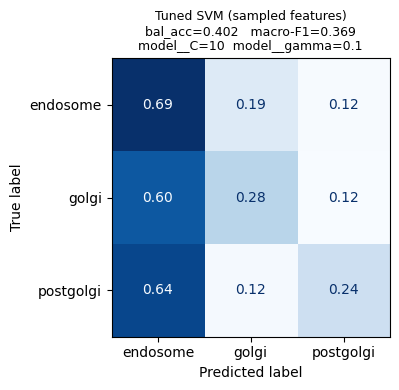

In [ ]:
y_pred_svm_tuned = gs_final.predict(X_test_sampled)

bal_acc_test = balanced_accuracy_score(y_test_sampled, y_pred_svm_tuned)
f1_test = f1_score(y_test_sampled, y_pred_svm_tuned, average='macro')

print("=== Tuned SVM — held-out test set (sampled features) ===")
print(classification_report(y_test_sampled, y_pred_svm_tuned, target_names=class_names))

cm = confusion_matrix(y_test_sampled, y_pred_svm_tuned)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', values_format='.2f', colorbar=False,
)
ax.set_title(
    f'Tuned SVM (sampled features)\n'
    f'bal_acc={bal_acc_test:.3f}   macro-F1={f1_test:.3f}\n'
    + '  '.join(f'{k}={v}' for k, v in gs_final.best_params_.items()),
    fontsize=9,
)
plt.tight_layout()
plt.savefig("svm_tuned_results.png", bbox_inches='tight', dpi=150)
plt.show()

=== Tuned SVM — held-out test set (full trajectories) ===
              precision    recall  f1-score   support

    endosome       0.36      0.82      0.50        38
       golgi       0.45      0.22      0.30        41
   postgolgi       0.50      0.13      0.21        38

    accuracy                           0.38       117
   macro avg       0.44      0.39      0.33       117
weighted avg       0.44      0.38      0.33       117



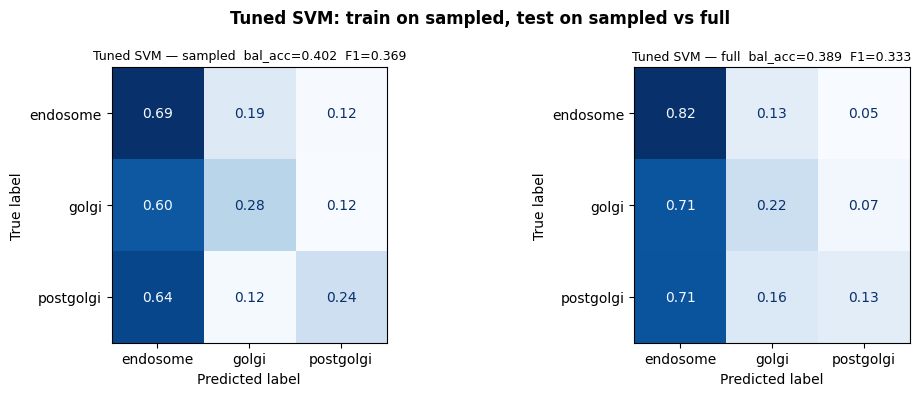

In [19]:
y_pred_svm_full = gs_final.predict(X_test_full)

bal_acc_full = balanced_accuracy_score(y_test_full, y_pred_svm_full)
f1_full = f1_score(y_test_full, y_pred_svm_full, average='macro')

print("=== Tuned SVM — held-out test set (full trajectories) ===")
print(classification_report(y_test_full, y_pred_svm_full, target_names=class_names))

cm_full = confusion_matrix(y_test_full, y_pred_svm_full)
cm_full_norm = cm_full.astype(float) / cm_full.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm_norm, y_test, y_pred, label in [
    (axes[0], cm.astype(float) / cm.sum(axis=1, keepdims=True),
     y_test_sampled, y_pred_svm_tuned, f'sampled  bal_acc={bal_acc_test:.3f}  F1={f1_test:.3f}'),
    (axes[1], cm_full_norm,
     y_test_full, y_pred_svm_full, f'full  bal_acc={bal_acc_full:.3f}  F1={f1_full:.3f}'),
]:
    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
        ax=ax, cmap='Blues', values_format='.2f', colorbar=False,
    )
    ax.set_title(f'Tuned SVM — {label}', fontsize=9)

fig.suptitle('Tuned SVM: train on sampled, test on sampled vs full', fontweight='bold')
plt.tight_layout()
plt.savefig("svm_tuned_sampled_vs_full.png", bbox_inches='tight', dpi=150)
plt.show()

In [20]:
param_grid = {
    'model__C':     [0.01, 0.1, 1, 10, 100],
    'model__gamma': ['scale', 1e-3, 1e-2, 1e-1],
}

svm_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED)),
])

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gs = GridSearchCV(
    svm_base,
    param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    refit=True,
)

# Nested CV: outer loop gives unbiased estimate, inner loop tunes hyperparams
nested_scores = cross_validate(
    gs,
    X_train_full,
    y_train_full,
    cv=outer_cv,
    scoring=['balanced_accuracy', 'f1_macro'],
    return_estimator=True,
    n_jobs=1,  # inner GridSearchCV already uses n_jobs=-1
)

bal_accs = nested_scores['test_balanced_accuracy']
f1s      = nested_scores['test_f1_macro']
print(f"Nested CV — balanced accuracy : {bal_accs.mean():.3f} ± {bal_accs.std():.3f}")
print(f"Nested CV — macro F1          : {f1s.mean():.3f} ± {f1s.std():.3f}")
print()
print("Best hyperparameters per outer fold:")
for i, est in enumerate(nested_scores['estimator']):
    print(f"  Fold {i + 1}: {est.best_params_}")

Nested CV — balanced accuracy : 0.627 ± 0.034
Nested CV — macro F1          : 0.563 ± 0.035

Best hyperparameters per outer fold:
  Fold 1: {'model__C': 1, 'model__gamma': 0.01}
  Fold 2: {'model__C': 10, 'model__gamma': 'scale'}
  Fold 3: {'model__C': 1, 'model__gamma': 0.1}
  Fold 4: {'model__C': 100, 'model__gamma': 0.001}
  Fold 5: {'model__C': 0.1, 'model__gamma': 'scale'}


In [21]:
gs_final = GridSearchCV(
    svm_base,
    param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    refit=True,
)
gs_final.fit(X_train_full, y_train_full)

print(f"Best params (full training set) : {gs_final.best_params_}")
print(f"Inner CV balanced accuracy      : {gs_final.best_score_:.3f}")

Best params (full training set) : {'model__C': 1, 'model__gamma': 'scale'}
Inner CV balanced accuracy      : 0.656


=== Tuned SVM — held-out test set (full trajectories) ===
              precision    recall  f1-score   support

    endosome       0.43      0.53      0.47        38
       golgi       0.52      0.61      0.56        41
   postgolgi       0.91      0.53      0.67        38

    accuracy                           0.56       117
   macro avg       0.62      0.55      0.57       117
weighted avg       0.62      0.56      0.57       117



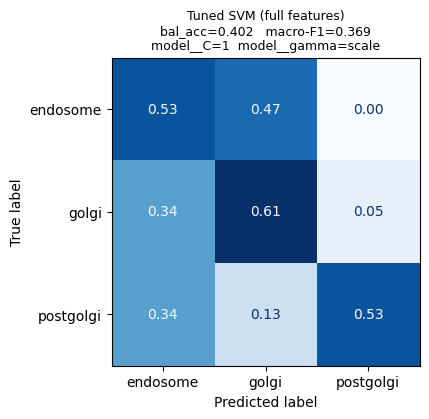

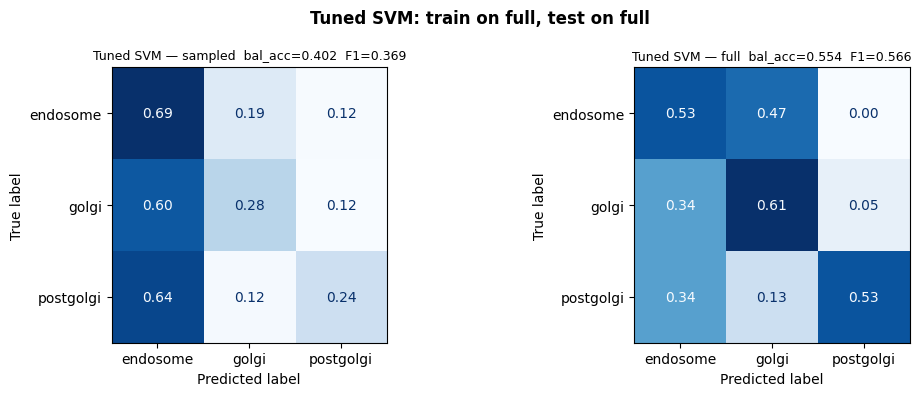

In [22]:
y_pred_svm_full = gs_final.predict(X_test_full)

bal_acc_full = balanced_accuracy_score(y_test_full, y_pred_svm_full)
f1_full = f1_score(y_test_full, y_pred_svm_full, average='macro')

print("=== Tuned SVM — held-out test set (full trajectories) ===")
print(classification_report(y_test_full, y_pred_svm_full, target_names=class_names))

cm_full = confusion_matrix(y_test_full, y_pred_svm_full)
cm_full_norm = cm_full.astype(float) / cm_full.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_full_norm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', values_format='.2f', colorbar=False,
)
ax.set_title(
    f'Tuned SVM (full features)\n'
    f'bal_acc={bal_acc_test:.3f}   macro-F1={f1_test:.3f}\n'
    + '  '.join(f'{k}={v}' for k, v in gs_final.best_params_.items()),
    fontsize=9,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm_norm, y_test, y_pred, label in [
    (axes[0], cm.astype(float) / cm.sum(axis=1, keepdims=True),
     y_test_sampled, y_pred_svm_tuned, f'sampled  bal_acc={bal_acc_test:.3f}  F1={f1_test:.3f}'),
    (axes[1], cm_full_norm,
     y_test_full, y_pred_svm_full, f'full  bal_acc={bal_acc_full:.3f}  F1={f1_full:.3f}'),
]:
    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
        ax=ax, cmap='Blues', values_format='.2f', colorbar=False,
    )
    ax.set_title(f'Tuned SVM — {label}', fontsize=9)

fig.suptitle('Tuned SVM: train on full, test on full', fontweight='bold')
plt.tight_layout()
plt.savefig("svm_tuned_full.png", bbox_inches='tight', dpi=150)
plt.show()